# Personal Portfolio Project: LSTM for Time Series

This notebook prepares hard-drive SMART sequences and trains LSTM-based models for failure prediction.

# Predictive Maintenance using NVIDIA RAPIDS and Deep Learning Models
#### Part 2: Training GPU LSTM models using Keras+Tensorflow for Time Series

## Overview

## Recurrent Networks: Long Short-Term Memory

## Vanishing Gradient Problem and LSTMs

## LSTM Cell Structure

## LSTM Applications

## Preparing the Environment


In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import os
import tensorflow as tf

print(tf.__version__)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

gpu=2 # set to number of GPU we want to leverage for training
tf.config.set_soft_device_placement(True) # set soft device placement to enabled
tf.debugging.set_log_device_placement(True) # turns logging for device placement decisions on
for each_device in tf.config.experimental.list_physical_devices('GPU'): 
    tf.config.experimental.set_memory_growth(each_device, True)


2.0.0


## Load Datasets for Data Preparation


In [3]:
import pandas as pd

data_dir = './data/'

train_pkl_file = 'Lab1-2017-Full-ST4000DM000.pkl'
test_pkl_file = 'Lab1-2016-Q4-ST4000DM000.pkl'

print("Reading in training and test SMART data stored in previous exercise...")
df_train = pd.read_pickle(data_dir+train_pkl_file)
df_test = pd.read_pickle(data_dir+test_pkl_file)

print(df_train.shape)
print(df_test.shape)


Reading in training and test SMART data stored in previous exercise...
(12237899, 53)
(3196552, 53)


In [4]:
df_train.head()


,date,serial_number,model,capacity_bytes,failure,smart_1_normalized,smart_1_raw,smart_3_normalized,smart_3_raw,smart_4_normalized,...,smart_198_normalized,smart_198_raw,smart_199_normalized,smart_199_raw,smart_240_normalized,smart_240_raw,smart_241_normalized,smart_241_raw,smart_242_normalized,smart_242_raw
4,2017-02-01,Z305B2QN,ST4000DM000,4000787030016,0,117.0,124084032.0,91.0,0.0,100.0,...,100.0,0.0,200.0,0.0,100.0,9690.0,100.0,3.179327e+10,100.0,8.596073e+09
7,2017-02-01,Z302A0YH,ST4000DM000,4000787030016,0,109.0,22057080.0,92.0,0.0,100.0,...,100.0,0.0,200.0,0.0,100.0,17310.0,100.0,2.169678e+10,100.0,1.860347e+11
8,2017-02-01,Z305BT0W,ST4000DM000,4000787030016,0,117.0,119535272.0,93.0,0.0,100.0,...,100.0,0.0,200.0,0.0,100.0,8514.0,100.0,2.755353e+10,100.0,1.631456e+10
12,2017-02-01,Z302A0YE,ST4000DM000,4000787030016,0,115.0,90592144.0,92.0,0.0,100.0,...,100.0,0.0,200.0,564.0,100.0,18051.0,100.0,2.150714e+10,100.0,2.376942e+11
13,2017-02-01,Z302PGH8,ST4000DM000,4000787030016,0,120.0,240109536.0,92.0,0.0,100.0,...,100.0,0.0,200.0,0.0,100.0,14303.0,100.0,1.645696e+10,100.0,7.311286e+10


In [5]:
def prepare_dataframe(df):
    print("Removing unnecessary columns")
    
    cols = [c for c in df.columns if (c.lower().find("normalized")!=-1)]
    df=df.drop(columns=cols)

    df = df.drop(columns=['model','capacity_bytes'])

    df['date'] = pd.to_datetime(df['date'])

    print("Sorting the data frame based on serial number and date")
    df = df.sort_values(by=['serial_number', 'date'], axis=0, ascending=True)
    df = df.reset_index(drop=True)
    
    df = df.fillna(0)
    
    return df


In [6]:
print("Processing train set...")
df_train = prepare_dataframe(df_train)

print("")
print("Processing test set...")
df_test = prepare_dataframe(df_test)


Processing train set...
Removing unnecessary columns
Sorting the data frame based on serial number and date

Processing test set...
Removing unnecessary columns
Sorting the data frame based on serial number and date


### Create sequences from data sets

### Preparing Training Data


In [7]:

def get_disk_serials(df, num_disks):
    failed_serials = df[df['failure'] == 1]['serial_number'].unique().tolist()

    df_tmp = df[~df.serial_number.isin(failed_serials)]
    normal_serials = df_tmp.serial_number.value_counts()[:num_disks].index.tolist()

    print('Normal Disk Serials:',len(normal_serials))
    print('Failed Disk Serials:',len(failed_serials))

    return normal_serials, failed_serials


In [8]:
import numpy as np

def adjust_dates(df_loc): 
    df_mod = pd.DataFrame()
    cur_serial = df_loc['serial_number'].unique().tolist()[0]
    col_list = df_loc.columns.tolist()
    cur_dates = df_loc['date'].values
    
    num_date_range = int((cur_dates[-1] - cur_dates[0]).astype('timedelta64[D]')/ np.timedelta64(1, 'D'))+1
    
    if num_date_range > cur_dates.shape[0]:
        i_low = 0
        
        for i in range(cur_dates.shape[0]-1): 
            
            diff_days = int((cur_dates[i+1] - cur_dates[i]).astype('timedelta64[D]')/ np.timedelta64(1, 'D'))
            
            if diff_days > 1:
                df_mod = df_mod.append(df_loc.iloc[i_low:i+1])
                tmp_array = np.empty((diff_days-1,len(col_list),))
                tmp_array[:] = np.nan
                df_add = pd.DataFrame(tmp_array,columns=col_list)
                df_add['date'] = [ cur_dates[i] + np.timedelta64(1, 'D')*j for j in range(1,diff_days)]
                df_mod = df_mod.append(df_add)
                i_low = i+1

        df_mod = df_mod.append(df_loc.iloc[i_low:])
        df_mod = df_mod.fillna(method="ffill")
    else:
        df_mod = df_loc 
    
    return df_mod 


In [9]:
def fix_date_gaps(df, normal_serials=None, failed_serials=None):
    df_fixed = pd.DataFrame()

    serials_list = normal_serials + failed_serials 
    for i, cur_serial in enumerate(serials_list): 
        df_fixed = df_fixed.append(adjust_dates(df[df['serial_number'] == cur_serial]))
        
    return df_fixed.reset_index(drop=True)


In [10]:
def create_failed_sequences(df, sequence_length, lookahead):

    failed_serials = df.serial_number.unique().tolist()
    print("Number of failed serials : ", len(failed_serials)) 

    failed_seq_list = []
    for serial in failed_serials:
        df_tmp = df[df['serial_number'] == serial]
        df_tmp = df_tmp.reset_index(drop=True)
        num_recs = df_tmp.index.size
        
        if num_recs > (sequence_length+lookahead): 
            df_failed = df_tmp[df_tmp['failure'] == 1]
            
            idx2 = df_failed.index[0] - lookahead + 1
            
            idx1 = idx2 - sequence_length
            
            if idx1 > 0: 
                failed_seq_list.append(df_tmp.iloc[idx1:idx2,:])
    
    print("Number of failed sequences :", len(failed_seq_list)) 
    
    return pd.concat(failed_seq_list)


In [11]:
def create_normal_sequences(df, sequence_length, num_normal, lookahead, day_step=1):
    normal_seq_list = []
    num_seq = 0
    
    if df[df['failure'] == 1].index.size > 0: return None 
    
    normal_serials = df.serial_number.unique().tolist()
    
    print("Number of normal serials : ", len(normal_serials)) 
    
    for serial in normal_serials:
        df_tmp = df[df['serial_number'] == serial]
        num_recs = df_tmp.shape[0]
        
        for i in range(0, num_recs-(sequence_length+lookahead)+1, day_step):
            if (num_seq < num_normal):
                normal_seq_list.append(df_tmp.iloc[i:i+sequence_length])
                num_seq += 1
    
    print("Number of normal sequences :", len(normal_seq_list))
    
    return pd.concat(normal_seq_list)


In [12]:
def label_sequence(df, label):
    df.insert(2, 'sequence_label', np.full(df.shape[0], label), True)
    return


In [13]:
sequence_length = 5          # Number of days in sequence to train to detect and predict failure
lookahead_days = 1           # Number of days in future to predict failure
num_normal_disks = 20        # Maximum number of normal disks to look at
max_normal_sequences = 4000  # Maximum number of normal sequences to create


In [14]:
print("Determining good and bad disk serial numbers")
normal_serials, bad_serials = get_disk_serials(df_train, num_normal_disks)

df_selected = df_train[df_train.serial_number.isin(normal_serials + bad_serials)]
print('Total Records before fixing date gaps :', df_selected.shape)

df_selected = fix_date_gaps(df_selected, normal_serials, bad_serials)
print('Total Records after fixing date gaps  :', df_selected.shape)
    
print("Creating sequences for normal disks")
normal_sequences = create_normal_sequences(df_selected[df_selected.serial_number.isin(normal_serials)], 
                                           sequence_length, max_normal_sequences, lookahead_days)

label_sequence(normal_sequences, 0)

print("Creating sequences for failed disks")
failure_sequences = create_failed_sequences(df_selected[df_selected.serial_number.isin(bad_serials)],
                                            sequence_length, lookahead_days)

label_sequence(failure_sequences, 1)

train_samples = pd.concat([normal_sequences, failure_sequences]).reset_index(drop=True)


Determining good and bad disk serial numbers
Normal Disk Serials: 20
Failed Disk Serials: 1061
Total Records before fixing date gaps : (189830, 27)
Total Records after fixing date gaps  : (194895, 27)
Creating sequences for normal disks
Number of normal serials :  20
Number of normal sequences : 4000
Creating sequences for failed disks
Number of failed serials :  1061
Number of failed sequences : 1041


In [15]:
normal_sequences.head(2*sequence_length)


,date,serial_number,sequence_label,failure,smart_1_raw,smart_3_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_9_raw,...,smart_191_raw,smart_192_raw,smart_193_raw,smart_194_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_240_raw,smart_241_raw,smart_242_raw
0,2017-01-01,Z304HQP8,0,0.0,175415544.0,0.0,3.0,0.0,402314576.0,9852.0,...,0.0,0.0,5200.0,24.0,0.0,0.0,0.0,9803.0,3.195901e+10,9.437334e+09
1,2017-01-02,Z304HQP8,0,0.0,67774136.0,0.0,3.0,0.0,402919411.0,9876.0,...,0.0,0.0,5200.0,24.0,0.0,0.0,0.0,9827.0,3.199398e+10,9.451381e+09
2,2017-01-03,Z304HQP8,0,0.0,124618984.0,0.0,3.0,0.0,403888842.0,9900.0,...,0.0,0.0,5200.0,24.0,0.0,0.0,0.0,9851.0,3.204838e+10,9.467967e+09
3,2017-01-04,Z304HQP8,0,0.0,209389760.0,0.0,3.0,0.0,404494071.0,9924.0,...,0.0,0.0,5200.0,23.0,0.0,0.0,0.0,9875.0,3.210276e+10,9.477457e+09
4,2017-01-05,Z304HQP8,0,0.0,90856304.0,0.0,3.0,0.0,405898472.0,9948.0,...,0.0,0.0,5201.0,24.0,0.0,0.0,0.0,9899.0,3.214668e+10,9.506257e+09
1,2017-01-02,Z304HQP8,0,0.0,67774136.0,0.0,3.0,0.0,402919411.0,9876.0,...,0.0,0.0,5200.0,24.0,0.0,0.0,0.0,9827.0,3.199398e+10,9.451381e+09
2,2017-01-03,Z304HQP8,0,0.0,124618984.0,0.0,3.0,0.0,403888842.0,9900.0,...,0.0,0.0,5200.0,24.0,0.0,0.0,0.0,9851.0,3.204838e+10,9.467967e+09
3,2017-01-04,Z304HQP8,0,0.0,209389760.0,0.0,3.0,0.0,404494071.0,9924.0,...,0.0,0.0,5200.0,23.0,0.0,0.0,0.0,9875.0,3.210276e+10,9.477457e+09
4,2017-01-05,Z304HQP8,0,0.0,90856304.0,0.0,3.0,0.0,405898472.0,9948.0,...,0.0,0.0,5201.0,24.0,0.0,0.0,0.0,9899.0,3.214668e+10,9.506257e+09
5,2017-01-06,Z304HQP8,0,0.0,208138872.0,0.0,3.0,0.0,406435910.0,9972.0,...,0.0,0.0,5201.0,24.0,0.0,0.0,0.0,9923.0,3.218460e+10,9.517656e+09


In [16]:
print('First Failure Sequence')
failure_sequences.head(sequence_length)


First Failure Sequence


,date,serial_number,sequence_label,failure,smart_1_raw,smart_3_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_9_raw,...,smart_191_raw,smart_192_raw,smart_193_raw,smart_194_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_240_raw,smart_241_raw,smart_242_raw
49,2017-02-19,S30070F5,1,0.0,83295096.0,0.0,8.0,0.0,531725607.0,25281.0,...,0.0,2.0,8249.0,30.0,0.0,0.0,0.0,25210.0,2.316110e+10,8.881304e+10
50,2017-02-20,S30070F5,1,0.0,73725216.0,0.0,8.0,0.0,532565600.0,25305.0,...,0.0,2.0,8249.0,29.0,0.0,0.0,0.0,25234.0,2.316667e+10,8.884915e+10
51,2017-02-21,S30070F5,1,0.0,41438696.0,0.0,8.0,0.0,533423914.0,25329.0,...,0.0,2.0,8249.0,29.0,0.0,0.0,0.0,25258.0,2.317391e+10,8.888442e+10
52,2017-02-22,S30070F5,1,0.0,25482720.0,0.0,8.0,0.0,534282220.0,25353.0,...,0.0,2.0,8249.0,30.0,0.0,0.0,0.0,25282.0,2.318148e+10,8.892227e+10
53,2017-02-23,S30070F5,1,0.0,233703728.0,0.0,8.0,0.0,535136227.0,25377.0,...,0.0,2.0,8249.0,29.0,0.0,0.0,0.0,25306.0,2.318899e+10,8.895852e+10


In [17]:
first_fail_serial = failure_sequences['serial_number'].iloc[0]
df_tmp = df_train[df_train['serial_number'] == first_fail_serial]
first_fail_index = df_tmp[df_tmp['failure'] == 1].iloc[0]

print("We should see a failure below",lookahead_days, "days after the sequence above.")
df_tmp[df_tmp['failure'] == 1].head(1)


We should see a failure below 1 days after the sequence above.


,date,serial_number,failure,smart_1_raw,smart_3_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_9_raw,smart_10_raw,...,smart_191_raw,smart_192_raw,smart_193_raw,smart_194_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_240_raw,smart_241_raw,smart_242_raw
16559,2017-02-24,S30070F5,1,184511376.0,0.0,8.0,0.0,535953309.0,25401.0,0.0,...,0.0,2.0,8249.0,29.0,0.0,0.0,0.0,25330.0,2.319425e+10,8.899058e+10


In [18]:
num_seq = int(train_samples.shape[0] / sequence_length)
print('Training Sequences:', num_seq)


Training Sequences: 5041


In [19]:
import gc

lab2_train_file = data_dir + 'Lab2-LSTM_train_data_' + str(sequence_length) + '.pkl'
lab2_test_file =  data_dir + 'Lab2-LSTM_test_data_' + str(sequence_length) + '.pkl'

train_samples.to_pickle(lab2_train_file)
del (train_samples)
gc.collect()


0

In [20]:
print("Determining good and bad disk serial numbers")
normal_serials, bad_serials = get_disk_serials(df_test, num_normal_disks)

df_selected = df_test[df_test.serial_number.isin(normal_serials + bad_serials)]
print('Total Records before fixing date gaps :', df_selected.shape)

df_selected = fix_date_gaps(df_selected, normal_serials, bad_serials)
print('Total Records after fixing date gaps  :', df_selected.shape)
    
print("Creating sequences for normal disks")
normal_sequences = create_normal_sequences(df_selected[df_selected.serial_number.isin(normal_serials)], 
                                           sequence_length, max_normal_sequences, lookahead_days)

label_sequence(normal_sequences, 0)

print("Creating sequences for failed disks")
failure_sequences = create_failed_sequences(df_selected[df_selected.serial_number.isin(bad_serials)],
                                            sequence_length, lookahead_days)

label_sequence(failure_sequences, 1)

test_samples = pd.concat([normal_sequences, failure_sequences]).reset_index(drop=True)


Determining good and bad disk serial numbers
Normal Disk Serials: 20
Failed Disk Serials: 234
Total Records before fixing date gaps : (12605, 27)
Total Records after fixing date gaps  : (12605, 27)
Creating sequences for normal disks
Number of normal serials :  20
Number of normal sequences : 1740
Creating sequences for failed disks
Number of failed serials :  234
Number of failed sequences : 216


In [21]:
test_samples.to_pickle(lab2_test_file)
del (test_samples)
gc.collect()


0

## Creating X and y labels


In [22]:
df_train = pd.read_pickle(lab2_train_file)
df_test = pd.read_pickle(lab2_test_file)

df_train.head(sequence_length)


,date,serial_number,sequence_label,failure,smart_1_raw,smart_3_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_9_raw,...,smart_191_raw,smart_192_raw,smart_193_raw,smart_194_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_240_raw,smart_241_raw,smart_242_raw
0,2017-01-01,Z304HQP8,0,0.0,175415544.0,0.0,3.0,0.0,402314576.0,9852.0,...,0.0,0.0,5200.0,24.0,0.0,0.0,0.0,9803.0,3.195901e+10,9.437334e+09
1,2017-01-02,Z304HQP8,0,0.0,67774136.0,0.0,3.0,0.0,402919411.0,9876.0,...,0.0,0.0,5200.0,24.0,0.0,0.0,0.0,9827.0,3.199398e+10,9.451381e+09
2,2017-01-03,Z304HQP8,0,0.0,124618984.0,0.0,3.0,0.0,403888842.0,9900.0,...,0.0,0.0,5200.0,24.0,0.0,0.0,0.0,9851.0,3.204838e+10,9.467967e+09
3,2017-01-04,Z304HQP8,0,0.0,209389760.0,0.0,3.0,0.0,404494071.0,9924.0,...,0.0,0.0,5200.0,23.0,0.0,0.0,0.0,9875.0,3.210276e+10,9.477457e+09
4,2017-01-05,Z304HQP8,0,0.0,90856304.0,0.0,3.0,0.0,405898472.0,9948.0,...,0.0,0.0,5201.0,24.0,0.0,0.0,0.0,9899.0,3.214668e+10,9.506257e+09


# Discuss your answers here:

### Exercise 1: Create class labels


In [23]:
drop_columns_list = ['date','serial_number', 'failure', 'sequence_label']

x_train = df_train.drop(columns=drop_columns_list)
x_test = df_test.drop(columns=drop_columns_list)

y_train = df_train['sequence_label']
y_test = df_test['sequence_label']


In [24]:
from sklearn import preprocessing

x_train = x_train.values.astype(np.float64)
scaler = preprocessing.StandardScaler().fit(x_train)
x_train = scaler.transform(x_train)

x_test = x_test.values.astype(np.float64)
x_test = scaler.transform(x_test)


### Exercise 2: Reshaping the training data


In [25]:
print("Reshaping training and test data for LSTM")
print("- Original Train Shape:", x_train.shape)

x_train = x_train.reshape(int(x_train.shape[0]/sequence_length), sequence_length, x_train.shape[1])
x_test = x_test.reshape(int(x_test.shape[0]/sequence_length), sequence_length, x_test.shape[1])

print("- Final Train Shape:   ", x_train.shape)
data_shape = x_train.shape[1:]


Reshaping training and test data for LSTM
- Original Train Shape: (25205, 24)
- Final Train Shape:    (5041, 5, 24)


In [26]:
y_train = y_train.values[0::sequence_length]

y_test = y_test.values[0::sequence_length]

gc.collect()


0

## Model Design


In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM

dp_lvl = 0.2
regularizer_lvl = 0.002
units = 64

strategy = tf.distribute.MirroredStrategy(devices=[f'/gpu:{device_id}' for device_id in range(gpu)])

with strategy.scope():
    model = Sequential()
    model.add(LSTM(units, input_shape=(x_train.shape[1], x_train.shape[2]),dropout = dp_lvl,recurrent_dropout = dp_lvl, return_sequences =  True ))
    model.add(LSTM(units, dropout = dp_lvl,recurrent_dropout = dp_lvl, return_sequences =  True ))
    model.add(LSTM(units, dropout = dp_lvl,recurrent_dropout = dp_lvl, return_sequences =  False ))


Executing op RandomUniform in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Sub in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Mul in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Add in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarIsInitializedOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op LogicalNot in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op Assert in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op AssignVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:1
Executing op VarIsInitializedOp in device /job:localhost/replica:0/task:0/device:GPU:1
Executing op LogicalNot in device /job:localho

In [27]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense, Dropout

with strategy.scope():
    model.add(Dense(units, activation='tanh',activity_regularizer=regularizers.l2(regularizer_lvl)))

    model.add(Dropout (0.2))
    model.add(Dense(units, activation='tanh',activity_regularizer=regularizers.l2(regularizer_lvl)))
    model.add(Dense(1, activation='tanh',activity_regularizer=regularizers.l2(regularizer_lvl)))


Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:1
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:1
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:1
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:1


In [28]:
model.summary()


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (None, 5, 64)             22784     
_________________________________________________________________
lstm_1 (LSTM)                (None, 5, 64)             33024     
_________________________________________________________________
lstm_2 (LSTM)                (None, 64)                33024     
_________________________________________________________________
dense (Dense)                (None, 64)                4160      
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 64)                4160      
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 6

## Training the Model


In [29]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

epochs_num = 50
learning_rate = 0.001
decay_rate = 3 * learning_rate / epochs_num
optimizer = Adam(lr=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=None,decay = decay_rate)

print('Training using %d GPU(s)' % strategy.num_replicas_in_sync)

with strategy.scope(): 
    model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy', 'mae'])

model_fn = "best_model.h5"
model_filepath=data_dir+model_fn

checkpoint = ModelCheckpoint(model_filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
es = EarlyStopping(patience=20, verbose=1)

callbacks_list = [es, checkpoint]


Training using 2 GPU(s)
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:1
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


In [30]:
history = model.fit(x_train, y_train, epochs=epochs_num, batch_size=16, validation_split=0.1, verbose=1, shuffle=True, callbacks=callbacks_list)


Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op Te

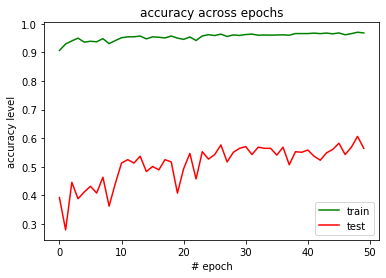

In [31]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],'g')
plt.plot(history.history['val_accuracy'],'r')
plt.title('accuracy across epochs')
plt.ylabel('accuracy level')
plt.xlabel('# epoch')
plt.legend(['train', 'test'], loc='lower right')
plt.show()


In [32]:
model.load_weights(model_filepath)

with strategy.scope(): 
    model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy', 'mae']) 
scores = model.evaluate(x_test, y_test, verbose=1)
print("%s: %.2f%% %s: %.2f%%" % (model.metrics_names[1], scores[1]*100, model.metrics_names[2], scores[2]*100))


Executing op ReadVariableOp in device /job:localhost/replica:0/task:0/device:GPU:1
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op GeneratorDataset in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op GeneratorDataset in device /job:localhost/replica:0/task:0/device:GPU:1
Executing op __inference_distributed_function_84166 in device /job:localhost/replica:0/task:0/device:GPU:0
1956/1 [========================================================

## Confusion Matrix - Reminder From the Previous Lab:


In [33]:
from sklearn.metrics import classification_report

y_pred = model.predict_classes(x_test)
conf_test = y_test.reshape(y_test.shape[0],1)
print(classification_report(conf_test, y_pred))


Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RebatchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op AutoShardDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op OptimizeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ModelDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MultiDeviceIterator in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op GeneratorDataset in device /job:localhost/replica:0/task:0/device:GPU:0
Ex

In [34]:
y_pred = model.predict_classes(x_train)
conf_train = y_train.reshape(y_train.shape[0],1)
print(classification_report(conf_train, y_pred))


Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op GeneratorDataset in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op GeneratorDataset in device /job:localhost/replica:0/task:0/device:GPU:1
Executing op __inference_distributed_function_87449 in device /job:localhost/replica:0/task:0/device:GPU:0
              precision    recall  f1-score   support

           0       0.93      1.00      0.97      4000
           1       1.00      0.73     

## CNN LSTM Architecture


In [35]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D

dp_lvl = 0.2
regularizer_lvl = 0.002
data_shape = x_train.shape[1:]

kernel_s = 3 # should be smaller than sequence length
filter_s = 64

with strategy.scope(): 
    model = Sequential()
    model.add(Conv1D(kernel_size = kernel_s, filters = filter_s, padding='same', input_shape=data_shape, activation='relu'))
    model.add(Conv1D(kernel_size = kernel_s, filters = filter_s, padding='same', activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(LSTM(filter_s, dropout = dp_lvl,recurrent_dropout = dp_lvl, return_sequences = True ))
    model.add(LSTM(filter_s, dropout = dp_lvl,recurrent_dropout = dp_lvl, return_sequences = False ))
    model.add(Dense(filter_s, activation='tanh',activity_regularizer=regularizers.l2(regularizer_lvl)))
    model.add(Dropout (0.2))
    model.add(Dense(1, activation='relu',activity_regularizer=regularizers.l2(regularizer_lvl)))

epochs_num = 100
learning_rate = 0.001
decay_rate = 3 * learning_rate / epochs_num
optimizer = Adam(lr=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=None,decay = decay_rate)

print('Training using %d GPU(s)' % strategy.num_replicas_in_sync)

model.summary()

model_fn = "best_1D_model.h5"
model_filepath=data_dir+model_fn

checkpoint = ModelCheckpoint(model_filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='auto')

es = EarlyStopping(patience=20, verbose=1)

callbacks_list = [es, checkpoint]

with strategy.scope(): 
    model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy', 'mae'])


Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:1
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:1
Training using 2 GPU(s)
Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d (Conv1D)              (None, 5, 64)             4672      
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 5, 64)             12352     
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 2, 64)             0         
_________________________________________________________________
lstm_3 (LSTM)                (None, 2, 64)             33024     
________________________________________

In [36]:
model.fit(x_train, y_train, epochs=epochs_num, batch_size=16, validation_split=0.1, verbose=1, shuffle=True, callbacks=callbacks_list)


Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Train on 4536 samples, validate on 505 samples
Epoch 1/100
Executing op GeneratorDataset in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op GeneratorDataset in device /job:localhost/replica:0/task:0/device:GPU:1
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:1
Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op VarHandleOp in devic

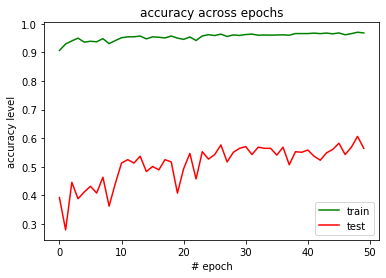

In [37]:
plt.plot(history.history['accuracy'],'g')
plt.plot(history.history['val_accuracy'],'r')
plt.title('accuracy across epochs')
plt.ylabel('accuracy level')
plt.xlabel('# epoch')
plt.legend(['train', 'test'], loc='lower right')
plt.show()


In [38]:
model.load_weights(model_filepath)

with strategy.scope(): 
    model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy', 'mae']) 
scores = model.evaluate(x_test, y_test, verbose=1)
print("%s: %.2f%% %s: %.2f%%" % (model.metrics_names[1], scores[1]*100, model.metrics_names[2], scores[2]*100))


Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op GeneratorDataset in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op GeneratorDataset in device /job:localhost/replica:0/task:0/device:GPU:1
Executing op __inference_distributed_function_207604 in device /job:localhost/replica:0/task:0/device:GPU:0
1956/1 [=================================================================================================================================================================================================================================================================================================================================================================================================================================================================================

In [39]:
y_pred = model.predict_classes(x_test)
conf_test = y_test.reshape(y_test.shape[0],1)
print(classification_report(conf_test, y_pred))


Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op GeneratorDataset in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op GeneratorDataset in device /job:localhost/replica:0/task:0/device:GPU:1
Executing op __inference_distributed_function_208956 in device /job:localhost/replica:0/task:0/device:GPU:0
              precision    recall  f1-score   support

           0       0.96      0.42      0.58      1740
           1       0.15      0.85      0.26       216

    accuracy                           0.47      1956
   macro avg       0.56      0.64      0.42      1956
weighted avg       0.87      0.47      0.55      1956



## Leveraging the model for calculating "Remaining Useful Life" (RUL)


In [42]:
gc.collect()


0

## Assessment – Predicting Time Series


In [38]:
!python try_assessment.py


{"score": 100, "message": "Your function is correct!"}


## Summary
